# Model 1 — Token Economics

**Question Answered:** _How throughput and token mix drive cost per token and margin._

**Question:** What does it cost to serve 1,000 output tokens, by product and GPU, and where does that cost come from?

## 1. Inputs & Assumptions

- **Source:** `inference_events` joined to `cost_constants`.
- **Cost model:** `cost = gpu_seconds × blended_cost_per_gpu_second` (compute + fixed power, grossed up by an overhead rate).
- **Unit:** cost per **1,000 output tokens** — output tokens are the expensive, customer-visible unit.
- **Why products differ:** output-heavy products are *decode-bound*. Decode is sequential and parallelises worse than prefill, so each output token of an output-heavy product consumes more GPU time.
- Synthetic, seeded data; constants illustrative.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({'figure.figsize':(9,4.5),'axes.spines.top':False,'axes.spines.right':False,
                     'axes.grid':True,'grid.alpha':0.3,'font.size':11})
NAVY, AMBER, GREY = '#1F3864', '#E1A140', '#9AA5B1'

conn = sqlite3.connect('../data/events.db')
pd.set_option('display.float_format', lambda v: f'{v:,.6f}')
print('rows:', pd.read_sql_query('SELECT COUNT(*) n FROM inference_events', conn).n[0])

rows: 120000


## 2. Working Code

### 2a. Cost decomposition by product × GPU (query Q1)

In [2]:
q = '''
SELECT e.product, e.gpu_type,
       SUM(e.tokens_output)                                            AS output_tokens,
       SUM(e.gpu_seconds * c.compute_cost_per_gpu_second)              AS compute_cost,
       SUM(e.gpu_seconds * c.power_cost_per_gpu_second)                AS power_cost,
       SUM(e.gpu_seconds * (c.compute_cost_per_gpu_second
                          + c.power_cost_per_gpu_second) * c.overhead_rate) AS overhead_cost,
       SUM(e.gpu_seconds * c.blended_cost_per_gpu_second)              AS total_cost
FROM inference_events e
JOIN cost_constants c USING (gpu_type)
GROUP BY e.product, e.gpu_type
'''
df = pd.read_sql_query(q, conn)
df.head()

,product,gpu_type,output_tokens,compute_cost,power_cost,overhead_cost,total_cost
0,ProductA,B200,1644148,0.270839,0.023438,0.052970,0.347247
1,ProductA,H100,4143765,0.730972,0.113426,0.151992,0.996389
2,ProductA,H200,2414745,0.397278,0.049660,0.080449,0.527386
3,ProductB,B200,1516949,0.249452,0.021587,0.048787,0.319826
4,ProductB,H100,3752679,0.661279,0.102612,0.137500,0.901390


### 2b. Cost per 1K output tokens by product, vs the blended baseline

In [3]:
prod = (df.groupby('product')[['output_tokens','compute_cost','power_cost','overhead_cost','total_cost']]
          .sum().reset_index())
prod['cost_per_1k'] = 1000 * prod.total_cost / prod.output_tokens
blended = 1000 * prod.total_cost.sum() / prod.output_tokens.sum()
prod['pct_vs_blended'] = 100 * (prod.cost_per_1k / blended - 1)
prod = prod.sort_values('cost_per_1k', ascending=False).reset_index(drop=True)
print(f'Blended cost per 1K output tokens: ${blended:.6f}')
prod[['product','output_tokens','cost_per_1k','pct_vs_blended']]

Blended cost per 1K output tokens: $0.000244


,product,output_tokens,cost_per_1k,pct_vs_blended
0,ProductC,9595885,0.000286,17.378671
1,ProductD,6518617,0.000230,-5.494566
2,ProductA,8202658,0.000228,-6.433518
3,ProductB,7585768,0.000228,-6.578348
4,ProductE,3829047,0.000226,-7.383819


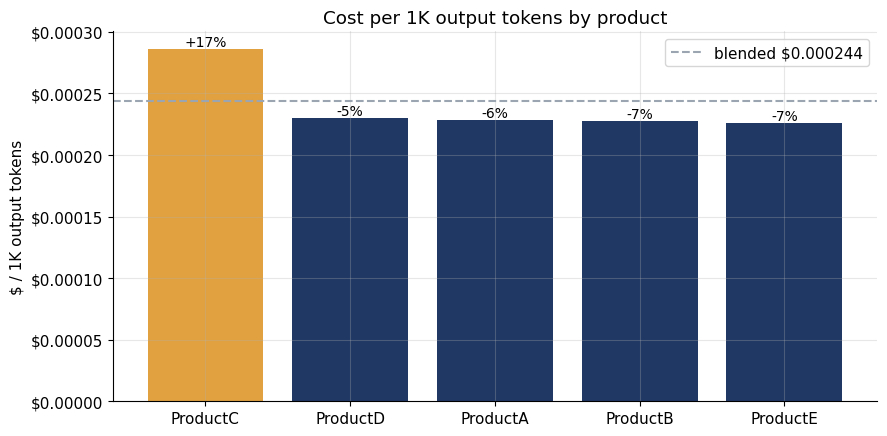

In [4]:
fig, ax = plt.subplots()
colors = [AMBER if v > 0 else NAVY for v in prod.pct_vs_blended]
ax.bar(list(prod['product']), prod.cost_per_1k.to_numpy(), color=colors)
ax.axhline(blended, color=GREY, ls='--', lw=1.5, label=f'blended ${blended:.6f}')
for x,(c,p) in enumerate(zip(prod.cost_per_1k, prod.pct_vs_blended)):
    ax.text(x, c, f'{p:+.0f}%', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('$ / 1K output tokens'); ax.set_title('Cost per 1K output tokens by product')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.5f')); ax.legend()
plt.tight_layout(); plt.show()

### 2c. Where the cost comes from (compute / power / overhead)

compute_cost    74.800000
power_cost      10.000000
overhead_cost   15.300000


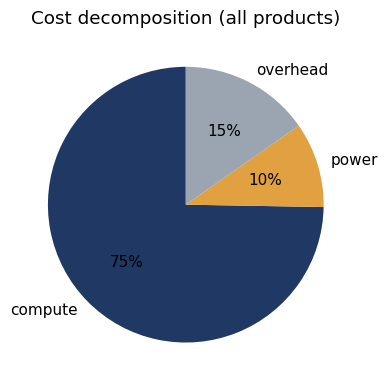

In [5]:
shares = prod[['compute_cost','power_cost','overhead_cost']].sum()
shares = (100*shares/shares.sum()).round(1)
print(shares.to_string())
fig, ax = plt.subplots(figsize=(6,4))
ax.pie(shares, labels=['compute','power','overhead'], autopct='%1.0f%%',
       colors=[NAVY,AMBER,GREY], startangle=90)
ax.set_title('Cost decomposition (all products)'); plt.tight_layout(); plt.show()

## 3. Insight

> **Cost per output token is set by decode efficiency, not headline token volume.** ProductC runs **~17% above** the blended cost per 1K output tokens — not because it is the largest product, but because it is output-heavy and *decode-bound*: its tokens are generated in the sequential phase that parallelises worst. Cost is **~75% compute, ~15% overhead, ~10% power**, so the lever that moves margin is GPU-time per output token (throughput), not the fixed power base.

**Margin inflection:** a product priced on a blended cost card loses money on its output-heavy traffic first. ProductC is the product to either reprice or route to higher-throughput GPUs (H200/B200) — that is where per-product margin inflects.

**Feeds:** this per-product cost basis is the margin input consumed by **Model 5 (Capacity Allocation)**.